# Part A: Support Vector Machine (SVM)

## Aim

To implement the Support Vector Machine (SVM) classifier for a binary classification problem and evaluate its performance.

## Dataset

**UCI Breast Cancer Wisconsin (Diagnostic) Dataset**

The dataset is used to classify breast tumors into two classes: malignant and benign.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

## Question 1: Load the Dataset and Perform the Necessary Preprocessing

Load the UCI Breast Cancer Wisconsin (Diagnostic) dataset and perform the necessary preprocessing.

The preprocessing includes:

- Loading the dataset.
- Separating the features and target variable.
- Checking the dataset dimensions.
- Checking for missing values.
- Examining the class distribution.
- Standardizing the numerical features before applying SVM.

In [3]:
# Load UCI Breast Cancer Wisconsin Diagnostic dataset
data = load_breast_cancer()

X = data.data
y = data.target

print("Dataset Shape:", X.shape)
print("Number of Features:", X.shape[1])
print("Number of Samples:", X.shape[0])

print("\nTarget Classes:")
print(data.target_names)

Dataset Shape: (569, 30)
Number of Features: 30
Number of Samples: 569

Target Classes:
['malignant' 'benign']


In [4]:
df = pd.DataFrame(X, columns=data.feature_names)
df["target"] = y

print(df.head())
print("\nMissing Values:")
print(df.isnull().sum().sum())

print("\nClass Distribution:")
print(df["target"].value_counts())

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  worst perimeter  worst area  \
0             

### Interpretation

The Breast Cancer Wisconsin dataset contains **569 samples and 30 numerical features**. The target variable contains two classes: **malignant** and **benign**.

The dataset contains **no missing values**, so no missing-value treatment is required.

The class distribution consists of **212 malignant samples and 357 benign samples**. Since the features have different numerical scales, feature standardization is performed before training the SVM model.

Standardization ensures that all features contribute appropriately to the SVM classification process.

## Question 2: Split the Dataset into Training and Testing Sets (80:20)

Split the dataset into training and testing sets using an **80:20 ratio**.

The training dataset is used to train the SVM classifier, while the testing dataset is used to evaluate the performance of the trained model on unseen data.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 455
Testing samples: 114


### Interpretation

The dataset was divided into **80% training data and 20% testing data**.

The resulting dataset contains:

- **455 training samples**
- **114 testing samples**

Stratified splitting was used so that the proportion of malignant and benign samples remains approximately consistent in both the training and testing datasets.

This provides a reliable basis for evaluating the model on previously unseen data.

In [6]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature standardization completed.")

Feature standardization completed.


## Question 3: Train an SVM Classifier Using a Linear Kernel and Explore Hyperparameter Tuning

Train a Support Vector Machine classifier using a **Linear Kernel**.

The regularization parameter **C** is tuned using Grid Search with 5-fold cross-validation.

The following values of C are evaluated:

$$
C = [0.01,\ 0.1,\ 1,\ 10,\ 100]
$$

The F1 score is used as the scoring metric for selecting the best hyperparameter.

In [7]:
svm_linear = SVC(
    kernel="linear",
    C=1
)

svm_linear.fit(X_train_scaled, y_train)

y_pred = svm_linear.predict(X_test_scaled)

In [8]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.9736842105263158
Precision: 0.9859154929577465
Recall   : 0.9722222222222222
F1 Score : 0.9790209790209791


In [9]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="linear"))
])

param_grid = {
    "svm__C": [0.01, 0.1, 1, 10, 100]
}

grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring="f1"
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation Score:", grid_search.best_score_)

Best Parameters: {'svm__C': 0.1}
Best Cross-Validation Score: 0.9827547753047131


### Interpretation

A Linear SVM was initially trained using **C = 1**. Hyperparameter tuning was then performed using Grid Search with 5-fold cross-validation.

The best value obtained was:

$$
C = 0.1
$$

The best cross-validation F1 score was:

$$
0.9827
$$

The value of C controls the regularization strength of the SVM. The selected value of **0.1** provided the best cross-validation performance among the tested values.

Therefore, the tuned SVM model with **C = 0.1** was selected for final evaluation.

## Question 4: Evaluate the Model Using Accuracy, Precision, Recall and F1 Score

Evaluate the tuned SVM classifier using the following classification metrics:

1. **Accuracy**
2. **Precision**
3. **Recall**
4. **F1 Score**

These metrics are used to measure different aspects of the classification performance.

In [10]:
best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))

Accuracy : 0.9825
Precision: 0.9861
Recall   : 0.9861
F1 Score : 0.9861


### Interpretation

The tuned Linear SVM achieved the following performance on the test dataset:

| Metric | Score |
|---|---:|
| Accuracy | **98.25%** |
| Precision | **98.61%** |
| Recall | **98.61%** |
| F1 Score | **98.61%** |

The accuracy of 98.25% indicates that the model correctly classified the majority of the test samples.

The high precision indicates that very few samples predicted as the positive class were incorrectly classified.

The high recall indicates that the model successfully identified most of the actual positive samples.

The F1 score of 98.61% demonstrates a strong balance between precision and recall.

Overall, the tuned SVM demonstrates excellent classification performance on the test dataset.

### Confusion Matrix

Generate and display the confusion matrix for the tuned SVM classifier.

The confusion matrix provides the number of:

- True Positives
- True Negatives
- False Positives
- False Negatives

In [11]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[41  1]
 [ 1 71]]


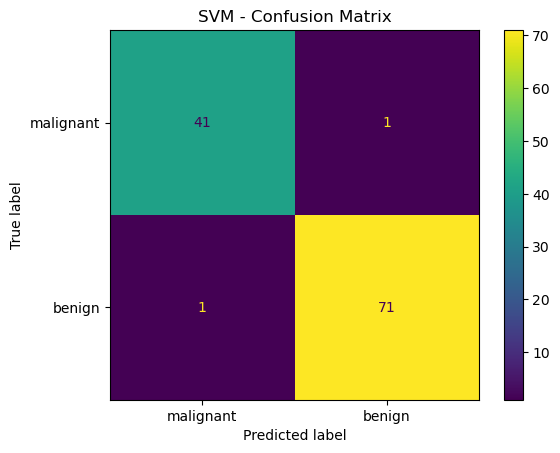

In [12]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=data.target_names
)

disp.plot()
plt.title("SVM - Confusion Matrix")
plt.show()

### Interpretation

The confusion matrix obtained for the tuned SVM model is:

$$
\begin{bmatrix}
41 & 1 \\
1 & 71
\end{bmatrix}
$$

This indicates that:

- **41** malignant samples were correctly classified.
- **1** malignant sample was incorrectly classified.
- **1** benign sample was incorrectly classified.
- **71** benign samples were correctly classified.

Therefore, only **2 out of 114 test samples** were misclassified.

The confusion matrix confirms that the tuned SVM model performs very well on the test dataset.

In [13]:
print(classification_report(
    y_test,
    y_pred,
    target_names=data.target_names
))

              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



## Question 5: Summarize Your Observations

### Observation

The Linear SVM classifier performed very well on the Breast Cancer Wisconsin Diagnostic dataset.

After hyperparameter tuning, **C = 0.1** was selected as the best regularization parameter based on 5-fold cross-validation.

The final model achieved:

- Accuracy: **98.25%**
- Precision: **98.61%**
- Recall: **98.61%**
- F1 Score: **98.61%**

The confusion matrix showed only two misclassified samples out of 114 test samples.

Feature standardization was also important because the dataset contains features with different scales.

### Conclusion

The results demonstrate that a Linear SVM with appropriate feature scaling and hyperparameter tuning is highly effective for this binary classification problem.

In [14]:
#PART B

# Part B: Principal Component Analysis (PCA)

## Aim

To implement Principal Component Analysis (PCA) for dimensionality reduction and analyse the variance retained by the principal components.

## Dataset

**UCI Wine Dataset**

The Wine dataset contains **178 samples, 13 numerical features, and 3 classes**.

## Question 1: Load the Dataset and Perform Feature Standardization

Load the UCI Wine dataset and standardize its 13 numerical features before applying PCA.

Feature standardization is performed using `StandardScaler`.

In [15]:
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [16]:
wine = load_wine()

X = wine.data
y = wine.target

print("Dataset Shape:", X.shape)
print("Number of Features:", X.shape[1])
print("Number of Samples:", X.shape[0])
print("Classes:", wine.target_names)

Dataset Shape: (178, 13)
Number of Features: 13
Number of Samples: 178
Classes: ['class_0' 'class_1' 'class_2']


In [17]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Standardization completed.")

Standardization completed.


### Interpretation

The Wine dataset contains **178 samples and 13 numerical features** belonging to **3 different classes**.

Since the features have different scales, standardization is performed before applying PCA.

After standardization, the features are transformed to have approximately zero mean and unit variance. This prevents features with larger numerical ranges from dominating the PCA transformation.

## Question 2: Apply PCA to Reduce the Dataset from 13 Features to 2 Principal Components

Apply PCA to transform the original Wine dataset from **13 features to 2 principal components**.

The transformed dataset will be used for two-dimensional visualization.

In [18]:
pca_2 = PCA(n_components=2)

X_pca = pca_2.fit_transform(X_scaled)

print("Original Shape:", X.shape)
print("Transformed Shape:", X_pca.shape)

Original Shape: (178, 13)
Transformed Shape: (178, 2)


### Interpretation

PCA successfully reduced the dataset from **13 features to 2 principal components**.

The original shape of the dataset was:

$$
178 \times 13
$$

After PCA, the transformed dataset has the shape:

$$
178 \times 2
$$

Therefore, the dimensionality was significantly reduced while retaining the same 178 samples.

The two principal components provide a simplified representation of the original high-dimensional dataset.

## Question 3: Display the Explained Variance Ratio of Each Principal Component

Calculate and display the explained variance ratio of the first two principal components.

The explained variance ratio represents the proportion of the total variance captured by each principal component.

In [19]:
explained_variance = pca_2.explained_variance_ratio_

print("Explained Variance Ratio:")
for i, variance in enumerate(explained_variance):
    print(f"Principal Component {i+1}: {variance:.4f}")

Explained Variance Ratio:
Principal Component 1: 0.3620
Principal Component 2: 0.1921


### Interpretation

The explained variance ratios obtained are:

| Principal Component | Explained Variance |
|---|---:|
| PC1 | **36.20%** |
| PC2 | **19.21%** |

Therefore, the first two principal components together retain:

$$
36.20\% + 19.21\% = 55.41\%
$$

of the total variance.

PC1 captures the largest amount of variance, while PC2 captures the second-largest amount of variance.

## Question 4: Calculate the Cumulative Explained Variance and Determine the Minimum Number of Principal Components Required to Retain at Least 95% Variance

Calculate the cumulative explained variance for all 13 principal components.

Determine the minimum number of principal components required to retain at least **95% of the total variance**.

In [20]:
pca_full = PCA()

X_pca_full = pca_full.fit_transform(X_scaled)

explained_variance = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

for i, variance in enumerate(cumulative_variance):
    print(
        f"Components: {i+1}, "
        f"Cumulative Variance: {variance:.4f}"
    )

Components: 1, Cumulative Variance: 0.3620
Components: 2, Cumulative Variance: 0.5541
Components: 3, Cumulative Variance: 0.6653
Components: 4, Cumulative Variance: 0.7360
Components: 5, Cumulative Variance: 0.8016
Components: 6, Cumulative Variance: 0.8510
Components: 7, Cumulative Variance: 0.8934
Components: 8, Cumulative Variance: 0.9202
Components: 9, Cumulative Variance: 0.9424
Components: 10, Cumulative Variance: 0.9617
Components: 11, Cumulative Variance: 0.9791
Components: 12, Cumulative Variance: 0.9920
Components: 13, Cumulative Variance: 1.0000


In [21]:
n_components_95 = np.argmax(
    cumulative_variance >= 0.95
) + 1

print(
    "Minimum number of components required "
    "for 95% variance:",
    n_components_95
)

Minimum number of components required for 95% variance: 10


### Interpretation

The cumulative explained variance increases as additional principal components are included.

The cumulative variance after the first two components is:

$$
55.41\%
$$

The cumulative variance after nine components is approximately:

$$
94.24\%
$$

This is below the required 95% threshold.

After including the tenth principal component, the cumulative variance becomes:

$$
96.17\%
$$

Therefore, the minimum number of principal components required to retain at least 95% of the total variance is:

$$
\boxed{10\ components}
$$

Thus, PCA can reduce the original 13 features to 10 components while retaining at least 95% of the variance.

## Question 5: Visualize the Transformed Dataset Using a Two-Dimensional Scatter Plot

Create a two-dimensional scatter plot using the first two principal components.

- **X-axis:** Principal Component 1
- **Y-axis:** Principal Component 2

The three wine classes should be represented separately in the plot.

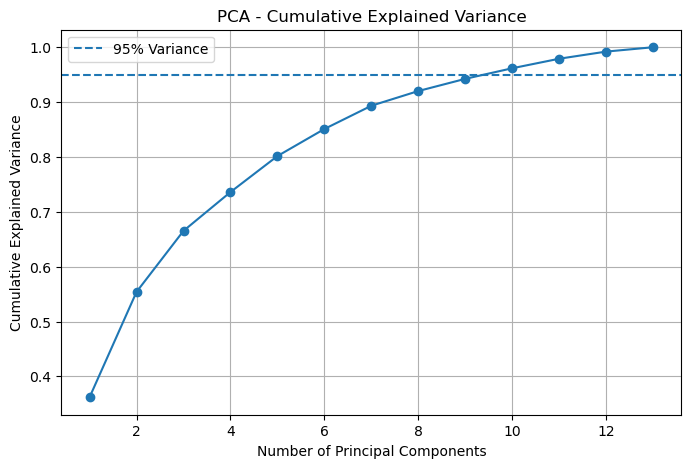

In [22]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker="o"
)

plt.axhline(
    y=0.95,
    linestyle="--",
    label="95% Variance"
)

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA - Cumulative Explained Variance")
plt.legend()
plt.grid(True)

plt.show()

### Interpretation

The scatter plot provides a two-dimensional representation of the original 13-dimensional Wine dataset.

The three wine classes can be visually compared in the PCA-transformed feature space.

Since PCA is an unsupervised dimensionality reduction technique, the principal components are selected based on maximum variance rather than class separation. Therefore, some overlap between classes may be observed in the two-dimensional representation.

The first two components retain approximately **55.41% of the total variance**, so the plot represents a substantial but not complete portion of the original information.

## Question 6: Compare the Original and Transformed Datasets

Compare the original and transformed datasets in terms of:

1. Number of features
2. Information retained
3. Computational efficiency

In [23]:
# Compare Original and Transformed Dataset

original_features = X.shape[1]
transformed_features = X_pca.shape[1]

original_variance = 1.0
retained_variance = pca_2.explained_variance_ratio_.sum()

print("Dataset Comparison")
print("-" * 40)

print(f"Original Number of Features     : {original_features}")
print(f"Transformed Number of Features : {transformed_features}")

print(f"\nOriginal Information Retained     : {original_variance * 100:.2f}%")
print(f"Transformed Information Retained : {retained_variance * 100:.2f}%")

print("\nComputational Efficiency:")
print(f"Feature Reduction : {original_features} → {transformed_features}")
print(f"Reduction         : {(1 - transformed_features/original_features) * 100:.2f}%")

Dataset Comparison
----------------------------------------
Original Number of Features     : 13
Transformed Number of Features : 2

Original Information Retained     : 100.00%
Transformed Information Retained : 55.41%

Computational Efficiency:
Feature Reduction : 13 → 2
Reduction         : 84.62%


### Interpretation

The original Wine dataset contains **13 features**, while the PCA-transformed dataset contains only **2 principal components**.

The first two principal components retain approximately **55.41% of the total variance** of the original dataset. Therefore, approximately 44.59% of the variance is not represented in the two-component transformation.

The number of features is reduced from 13 to 2, which represents an **84.62% reduction in dimensionality**. This reduction can improve computational efficiency for subsequent machine learning algorithms because fewer features need to be processed.

Therefore, PCA provides a trade-off between dimensionality reduction and information retention.

## Question 7: Interpret the Significance of the First Two Principal Components

Interpret the significance of Principal Component 1 (PC1) and Principal Component 2 (PC2) based on their explained variance ratios.

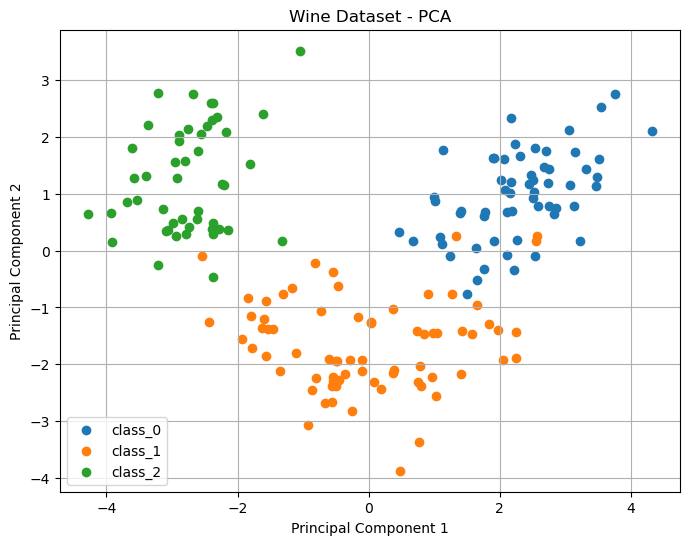

In [24]:
plt.figure(figsize=(8, 6))

for target in np.unique(y):
    plt.scatter(
        X_pca[y == target, 0],
        X_pca[y == target, 1],
        label=wine.target_names[target]
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Wine Dataset - PCA")
plt.legend()
plt.grid(True)

plt.show()

### Interpretation

PC1 explains approximately **36.20%** of the total variance and represents the direction containing the largest amount of variation in the standardized Wine dataset.

PC2 explains approximately **19.21%** of the total variance and represents the second-largest direction of variation.

Together, PC1 and PC2 explain approximately **55.41%** of the total variance.

Thus, the first two principal components provide a useful two-dimensional representation of the original 13-dimensional dataset, although some information is lost during the reduction.

## Question 8: Discuss the Advantages, Limitations, and Applications of PCA

### Advantages

- Reduces the dimensionality of high-dimensional datasets.
- Makes high-dimensional data easier to visualize.
- Can reduce computational complexity.
- Produces uncorrelated principal components.
- Can help reduce noise.
- Can be used for feature extraction.

### Limitations

- PCA does not use class labels.
- Principal components can be difficult to interpret.
- PCA is sensitive to feature scaling.
- Some information is lost when components are removed.
- Maximum variance does not necessarily result in maximum class separability.
- PCA mainly captures linear relationships.

### Applications

PCA is commonly used in:

- Image processing
- Face recognition
- Data visualization
- Feature extraction
- Noise reduction
- Bioinformatics
- Financial analysis
- Pattern recognition
- Machine learning preprocessing
- High-dimensional data analysis

## Extra Credit Task: Linear Discriminant Analysis (LDA)

Apply **Linear Discriminant Analysis (LDA)** to the same Wine dataset and reduce it to two linear discriminants.

Visualize the transformed data and compare the results with PCA in terms of:

1. Dimensionality reduction
2. Class separability

Finally, summarize the observations.

In [26]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

In [27]:
# Compare Original and PCA-Transformed Dataset

original_features = X.shape[1]
pca_features = X_pca.shape[1]

pca_variance_retained = pca_2.explained_variance_ratio_.sum()

feature_reduction = (
    (original_features - pca_features) / original_features
) * 100

print("PCA Dataset Comparison")
print("-" * 40)

print("Original Number of Features :", original_features)
print("PCA Number of Features      :", pca_features)

print(f"\nInformation Retained by 2 PCs: "
      f"{pca_variance_retained * 100:.2f}%")

print(f"Feature Reduction            : "
      f"{feature_reduction:.2f}%")

PCA Dataset Comparison
----------------------------------------
Original Number of Features : 13
PCA Number of Features      : 2

Information Retained by 2 PCs: 55.41%
Feature Reduction            : 84.62%


### 1. Apply LDA and Reduce the Dataset to Two Linear Discriminants

Apply Linear Discriminant Analysis (LDA) to the standardized Wine dataset and reduce the original 13 features to two linear discriminants.

Since the Wine dataset contains three classes, the maximum number of LDA components is:

$$
C - 1 = 3 - 1 = 2
$$

In [28]:
lda = LinearDiscriminantAnalysis(
    n_components=2
)

X_lda = lda.fit_transform(
    X_scaled,
    y
)

print("Original Shape:", X.shape)
print("LDA Shape:", X_lda.shape)

Original Shape: (178, 13)
LDA Shape: (178, 2)


### 2. Visualize the LDA Transformed Dataset

Visualize the transformed Wine dataset using a two-dimensional scatter plot.

- **X-axis:** Linear Discriminant 1
- **Y-axis:** Linear Discriminant 2

The three wine classes should be represented separately.

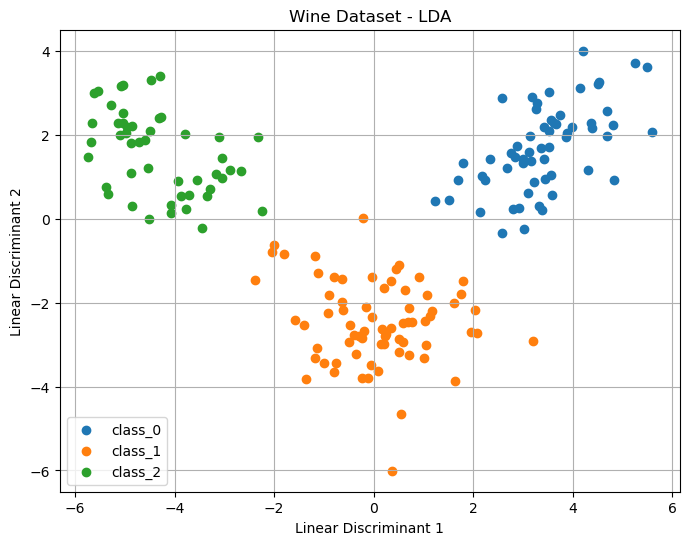

In [29]:
plt.figure(figsize=(8, 6))

for target in np.unique(y):
    plt.scatter(
        X_lda[y == target, 0],
        X_lda[y == target, 1],
        label=wine.target_names[target]
    )

plt.xlabel("Linear Discriminant 1")
plt.ylabel("Linear Discriminant 2")
plt.title("Wine Dataset - LDA")
plt.legend()
plt.grid(True)

plt.show()

### Interpretation

The LDA scatter plot represents the original 13-dimensional Wine dataset in a two-dimensional space.

Since LDA uses the class labels during dimensionality reduction, it focuses on maximizing the separation between the three wine classes.

Therefore, the classes are expected to show clearer separation in the LDA-transformed space compared with the PCA-transformed space.

### 3. Compare Class Separability Using Silhouette Score

Calculate the Silhouette Score for both the PCA and LDA transformed datasets.

The Silhouette Score is used to quantitatively compare the separation of the three wine classes in the reduced feature spaces.

A higher Silhouette Score indicates better class separability.

In [30]:
from sklearn.metrics import silhouette_score

pca_score = silhouette_score(X_pca, y)
lda_score = silhouette_score(X_lda, y)

print("PCA Silhouette Score:", round(pca_score, 4))
print("LDA Silhouette Score:", round(lda_score, 4))

PCA Silhouette Score: 0.5262
LDA Silhouette Score: 0.6632


### 4. Compare PCA and LDA in Terms of Dimensionality Reduction and Class Separability

Compare PCA and LDA based on:

- Number of original features
- Number of reduced features
- Percentage of feature reduction
- Class separability using the Silhouette Score

In [ ]:


pca_features = X_pca.shape[1]
lda_features = X_lda.shape[1]

pca_reduction = (
    (X.shape[1] - pca_features) / X.shape[1]
) * 100

lda_reduction = (
    (X.shape[1] - lda_features) / X.shape[1]
) * 100

print("PCA vs LDA Comparison")
print("=" * 50)

print("\nDimensionality Reduction:")
print(f"PCA: {X.shape[1]} → {pca_features} features")
print(f"LDA: {X.shape[1]} → {lda_features} features")

print(f"\nPCA Feature Reduction: {pca_reduction:.2f}%")
print(f"LDA Feature Reduction: {lda_reduction:.2f}%")

print("\nClass Separability:")
print(f"PCA Silhouette Score: {pca_score:.4f}")
print(f"LDA Silhouette Score: {lda_score:.4f}")

if lda_score > pca_score:
    print("\nConclusion: LDA provides better class separability.")
elif pca_score > lda_score:
    print("\nConclusion: PCA provides better class separability.")
else:
    print("\nConclusion: Both methods provide the same class separability.")

PCA vs LDA Comparison

Dimensionality Reduction:
PCA: 13 → 2 features
LDA: 13 → 2 features

PCA Feature Reduction: 84.62%
LDA Feature Reduction: 84.62%

Class Separability:
PCA Silhouette Score: 0.5262
LDA Silhouette Score: 0.6632

Conclusion: LDA provides better class separability.


### Interpretation

Both PCA and LDA reduce the original Wine dataset from **13 features to 2 dimensions**.

The dimensionality reduction achieved by both methods is:

$$
13 \rightarrow 2
$$

This represents an **84.62% reduction in the number of features**.

However, PCA and LDA have different objectives. PCA is an **unsupervised** dimensionality reduction technique that focuses on maximizing the variance retained in the data without using class labels. LDA is a **supervised** technique that uses class labels and focuses on maximizing class separability.

The Silhouette Scores obtained are:

| Method | Reduced Features | Feature Reduction | Silhouette Score |
|---|---:|---:|---:|
| PCA | 2 | 84.62% | **0.5262** |
| LDA | 2 | 84.62% | **0.6632** |

Both methods achieve the same dimensionality reduction. However, LDA has a higher Silhouette Score (**0.6632**) compared with PCA (**0.5262**).

Therefore, LDA provides better class separability than PCA for the Wine dataset in this experiment.

PCA is more focused on preserving overall variance, while LDA is more suitable when the objective is to obtain a reduced representation with better separation between known classes.